<a href="https://colab.research.google.com/github/Storm00212/SIGNALS-ASSIGNMENT-1/blob/main/QUESTION_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install scikit-commpy


import numpy as np
import matplotlib.pyplot as plt
!pip install komm
import komm


QUESTION A

# GENERATING MAGNITUDE AND FREQUENCY RESPONSE FOR RAISED COSINE MANUALLY THEN COMPARING THEM WITH THE FUNCTIONS IN THE KOMM LIB

# since the raised cosine function has 3 parts i used if else statements to generate the function for different values of t this was the formula in t domain
\(h(t)=\begin{cases}\frac{1}{T_{s}}&\text{for\ }t=0\\ \frac{1}{2T_{s}}\text{sinc}\left(\frac{1}{2\beta }\right)=\frac{\beta }{2T_{s}}\sin \left(\frac{\pi }{2\beta }\right)&\text{for\ }t=\pm \frac{T_{s}}{2\beta }\\ \frac{1}{T_{s}}\text{sinc}\left(\frac{t}{T_{s}}\right)\frac{\cos \left(\frac{\pi \beta t}{T_{s}}\right)}{1-\left(\frac{2\beta t}{T_{s}}\right)^{2}}&\text{otherwise}\end{cases}\)

so you have to use if else for h based on the value of t when making the rc_pulse function

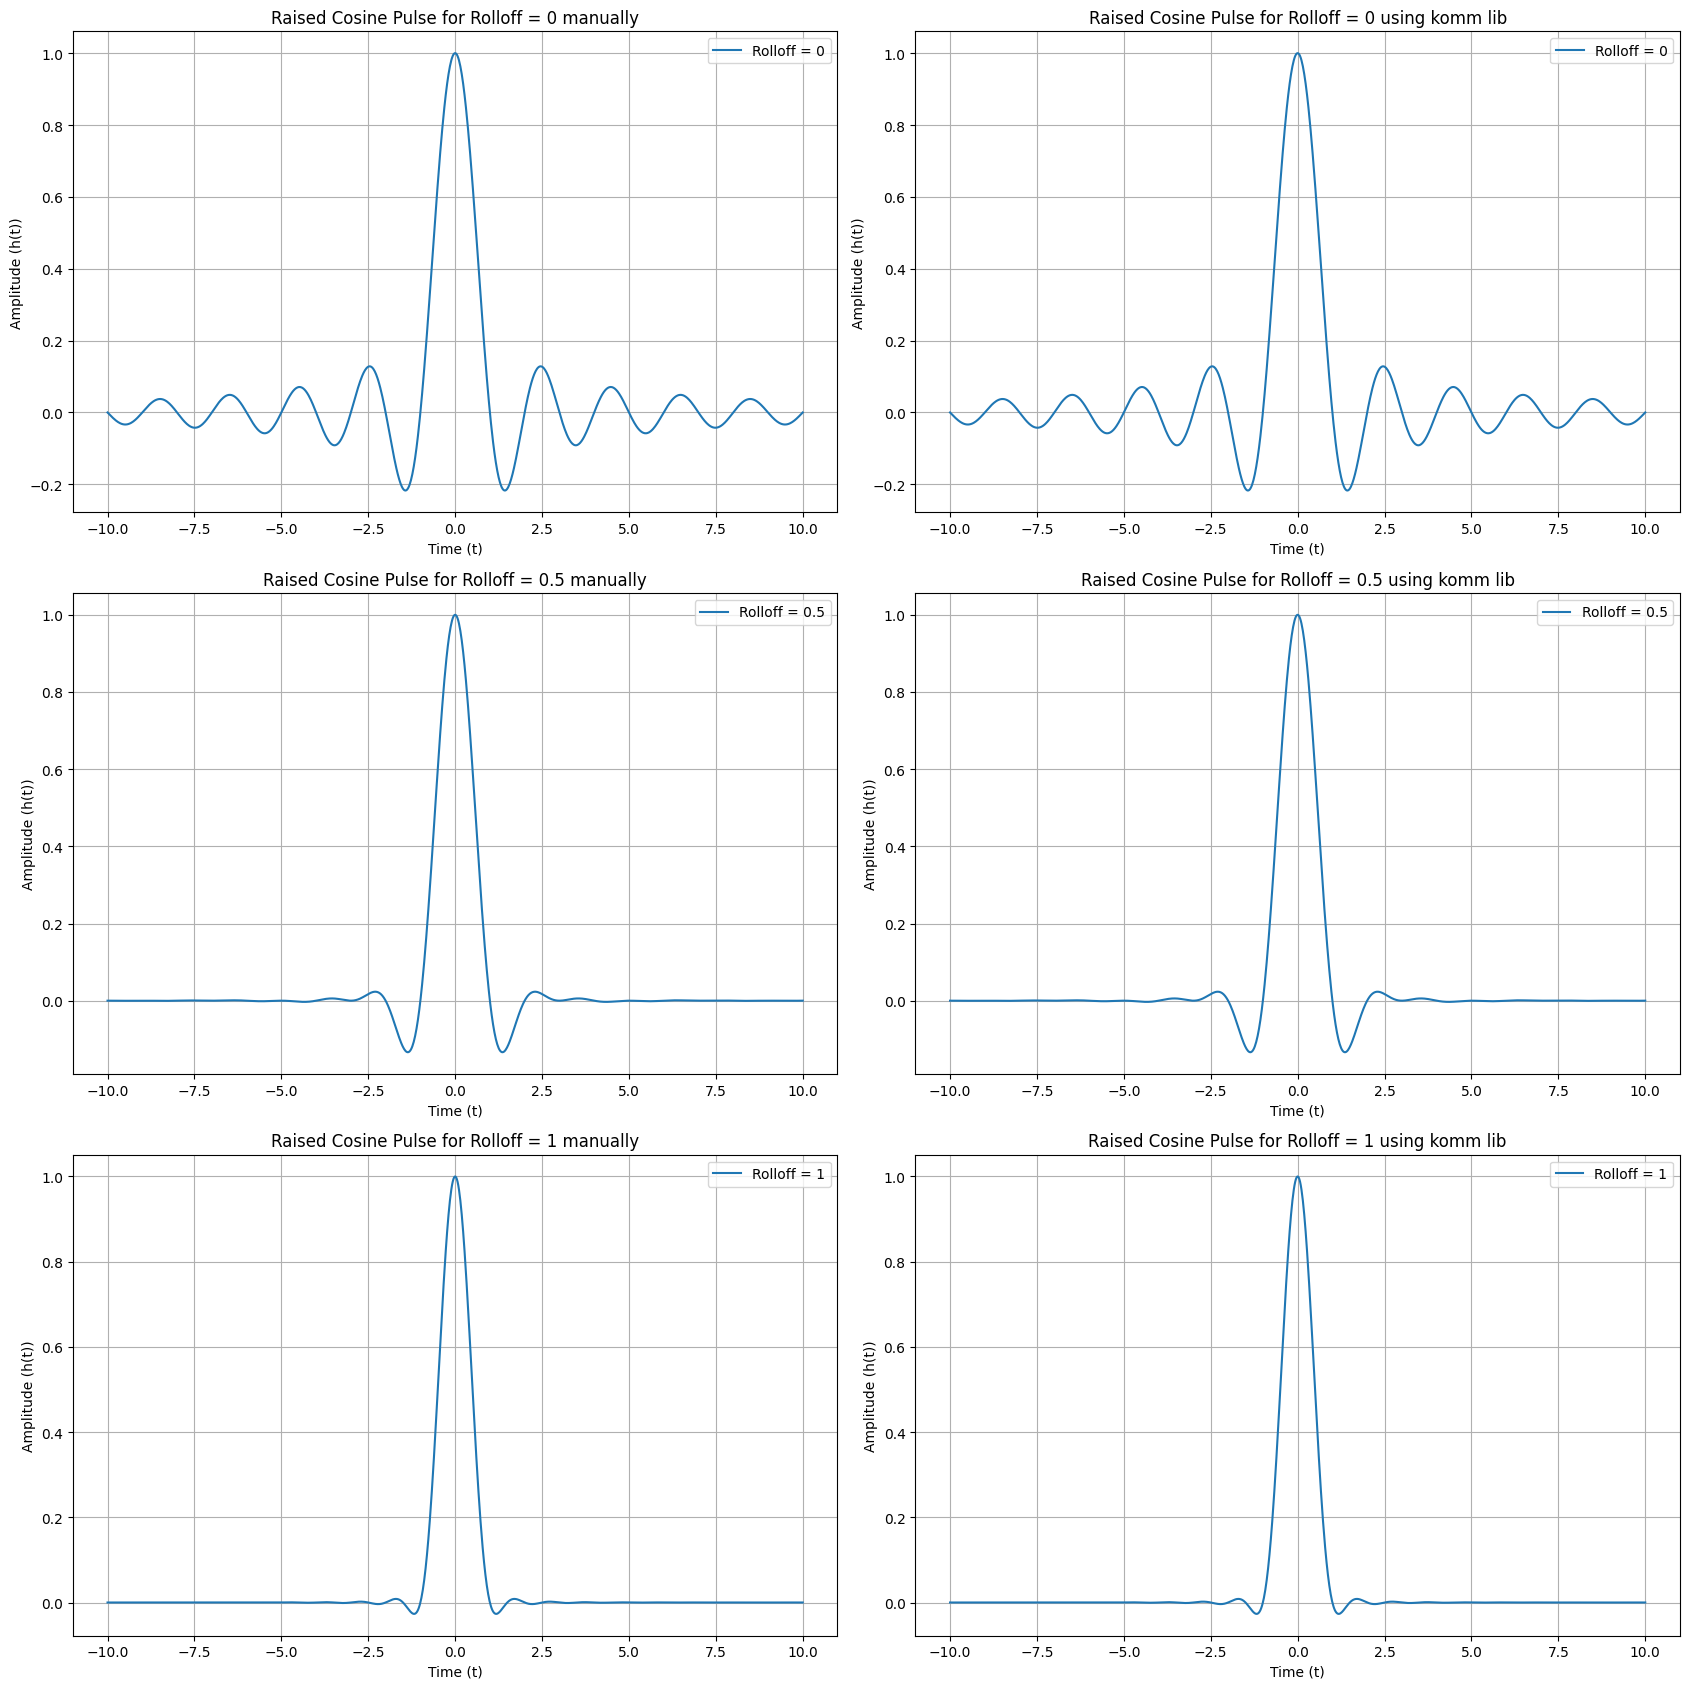

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import komm

# MANUALLY and using compy
Ts = 1
rolloffs = [0, 0.5, 1]

def rc_pulse(t, Ts, B):
    "computes the rc function for each point t"
    # Ensure t is a numpy array so we handle this well cuz t is continuous
    t_array = np.asarray(t, dtype=float)

    # Handle the special case where rolloff factor B is 0 (ideal sinc filter)
    #this gave me issues fr.
    if B == 0:
        return (1 / Ts) * np.sinc(t_array / Ts)

    with np.errstate(divide='ignore', invalid='ignore'):
        # numerator and denominator for the general formula
        numerator = np.cos((np.pi * B * t_array) / Ts)
        denominator = 1 - ((2 * B * t_array) / Ts)**2

        # Calculate b_vals, np.sinc handles t_array=0 correctly
        b_vals = (1 / Ts) * np.sinc(t_array / Ts)

        # Initialize h_vals. Use np.divide to handle division by zero for 'a_vals' gracefully
        # Points where denominator is zero (special cases) will be overwritten later.
        a_vals = np.divide(numerator, denominator, out=np.zeros_like(numerator), where=denominator!=0)
        h_vals = a_vals * b_vals # for condition 3(otherwise)

        # Apply specific conditions to overwrite h_vals at special points

        # Condition 1: t == 0
        zero_mask = (t_array == 0)
        h_vals[zero_mask] = 1 / Ts

        # Condition 2: t == +/- Ts /2B
        # These are the points where 'denominator' would be zero in the general formula.
        abs_Ts_2B = Ts / (2 * B)
        # Use np.isclose for robust floating-point comparison for these special points
        # isclose just takes any value that is close to the ones we want (+/- Ts/2B)
        special_point_mask = np.isclose(t_array, abs_Ts_2B) | np.isclose(t_array, -abs_Ts_2B)
        h_vals[special_point_mask] = (1 / (2 * Ts)) * np.sinc(1 / (2 * B))

    return h_vals

# 2 cols to compare side by side.
fig, axes = plt.subplots(3, 2, figsize=(17, 17))
t = np.linspace(-10, 10, 1000)
# thought i'd do a side by side comparison
for i, rolloff in enumerate(rolloffs):
    h = rc_pulse(t, Ts, rolloff)
    #  RaisedCosinePulse object with the rolloff factor
    K_pulse_filter = komm.RaisedCosinePulse(rolloff)
    # Get the impulse response values by calling the pulse filter object with the time array
    K_values = K_pulse_filter.waveform(t)
    axes[i,0].plot(t, h, label=f'Rolloff = {rolloff}')
    axes[i,0].set_title(f'Raised Cosine Pulse for Rolloff = {rolloff} manually')
    axes[i,0].set_xlabel('Time (t)')
    axes[i,0].set_ylabel('Amplitude (h(t))')
    axes[i,0].legend()
    axes[i,0].grid(True)

    axes[i,1].plot(t, K_values, label=f'Rolloff = {rolloff}')
    axes[i,1].set_title(f'Raised Cosine Pulse for Rolloff = {rolloff} using komm lib')
    axes[i,1].set_xlabel('Time (t)')
    axes[i,1].set_ylabel('Amplitude (h(t))')
    axes[i,1].legend()
    axes[i,1].grid(True)

plt.tight_layout()
plt.show()

# NOW FOR THE FOURIER TRANSFORMS

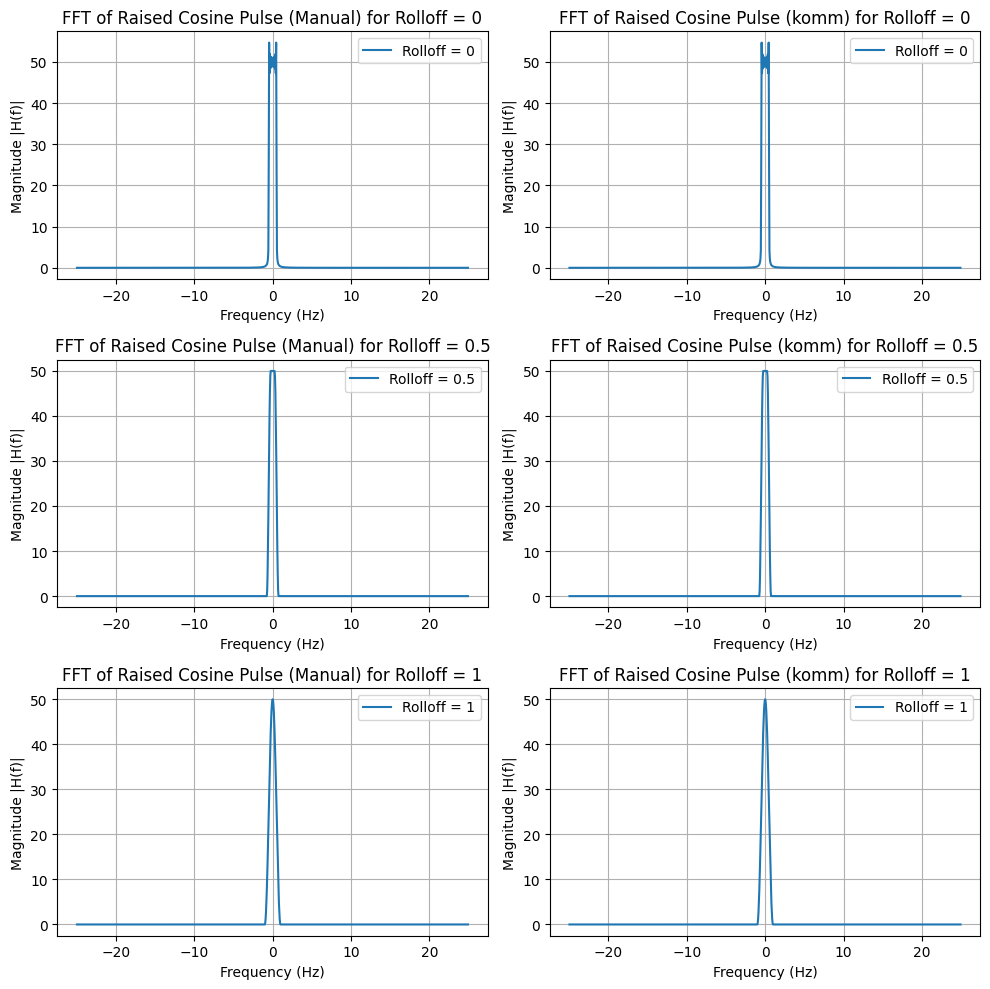

In [3]:
# just taking fourier transforms of the functions above and iterating them for the 3 rolloffs.
fig, axes = plt.subplots(3, 2, figsize=(10, 10))
t = np.linspace(-10, 10, 1000)
dt = t[1] - t[0] #interval for frequency axis

for i, rolloff in enumerate(rolloffs):
    # Manual pulse FFT
    h = rc_pulse(t, Ts, rolloff)
    h_fft = np.fft.fftshift(np.fft.fft(h))

    # komm library pulse FFT
    komm_pulse_filter = komm.RaisedCosinePulse(rolloff) # Instantiate for current rolloff
    K_values_for_fft = komm_pulse_filter.waveform(t) # Get waveform from instance(used docs for this)
    K_values_fft = np.fft.fftshift(np.fft.fft(K_values_for_fft))#shift for better waveform

    frequency = np.fft.fftshift(np.fft.fftfreq(len(t), d=dt))

    # Plot for manual pulse FFT
    axes[i,0].plot(frequency, np.abs(h_fft), label=f'Rolloff = {rolloff}')
    axes[i,0].set_title(f'FFT of Raised Cosine Pulse (Manual) for Rolloff = {rolloff}')
    axes[i,0].set_xlabel('Frequency (Hz)')
    axes[i,0].set_ylabel('Magnitude |H(f)|')
    axes[i,0].legend()
    axes[i,0].grid(True)

    # Plot for komm library pulse FFT
    axes[i,1].plot(frequency, np.abs(K_values_fft), label=f'Rolloff = {rolloff}')
    axes[i,1].set_title(f'FFT of Raised Cosine Pulse (komm) for Rolloff = {rolloff}')
    axes[i,1].set_xlabel('Frequency (Hz)')
    axes[i,1].set_ylabel('Magnitude |H(f)|')
    axes[i,1].legend()
    axes[i,1].grid(True)

plt.tight_layout()
plt.show()

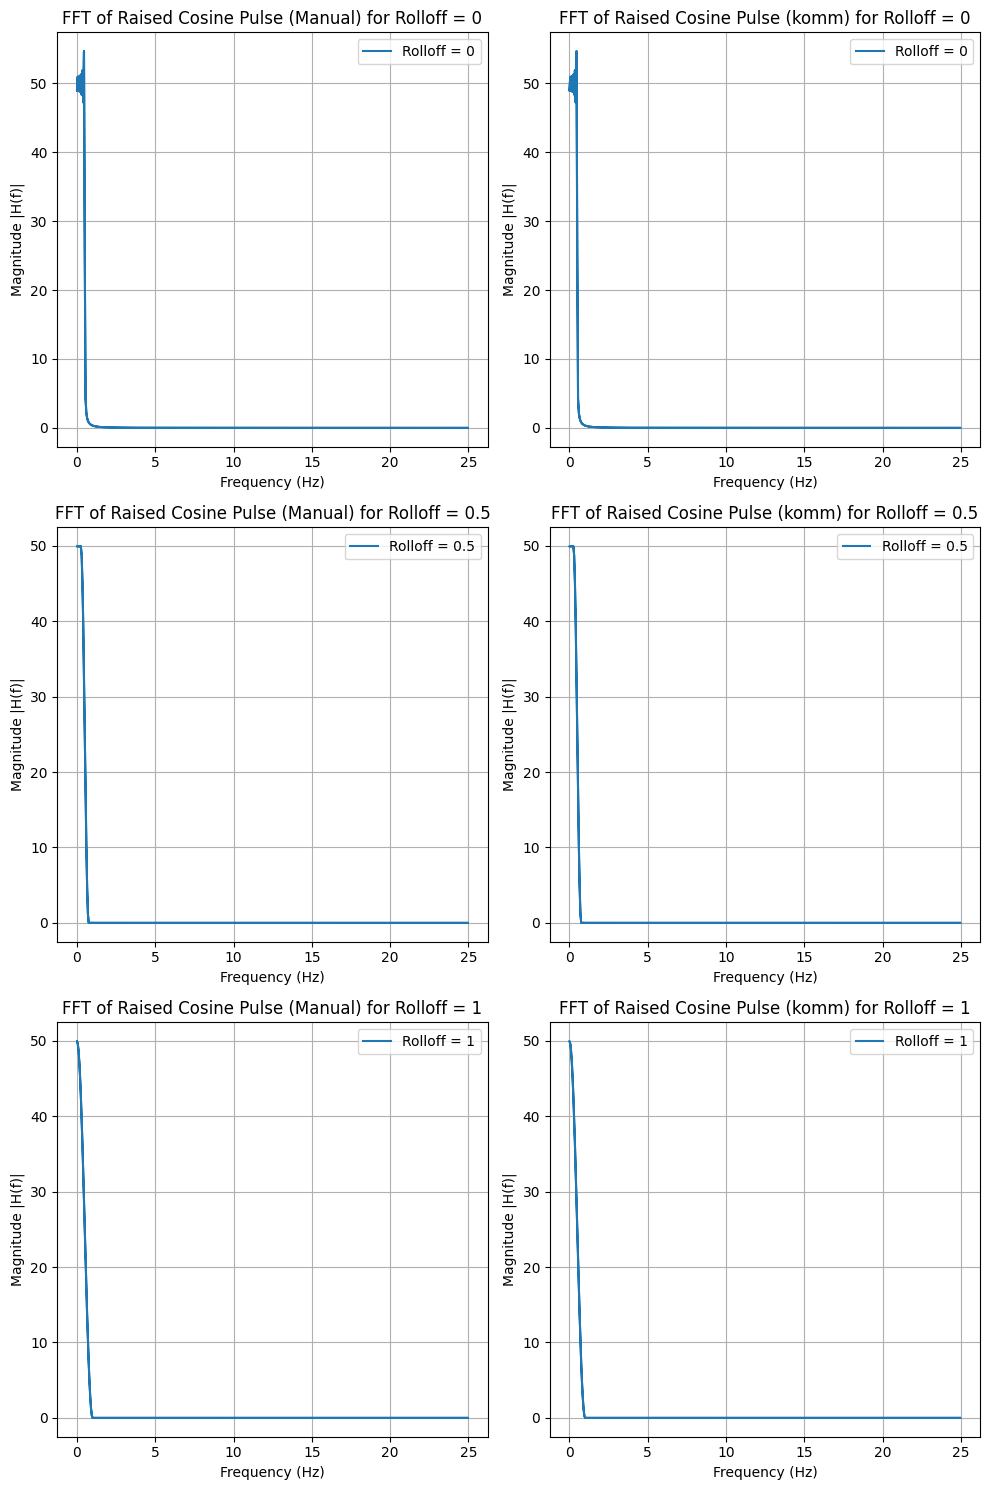

In [4]:
# for absolute frequency justget magnitude of frequency using np.abs(frequency)
# THIS MATCHES THE RESPONSE SHOWN IN THE NOTES FOR RC FILTER.
fig, axes = plt.subplots(3, 2, figsize=(10, 15))
t = np.linspace(-10, 10, 1000)
dt = t[1] - t[0]

for i, rolloff in enumerate(rolloffs):

    h = rc_pulse(t, Ts, rolloff)
    h_fft = np.fft.fftshift(np.fft.fft(h))


    komm_pulse_filter = komm.RaisedCosinePulse(rolloff)
    K_values_for_fft = komm_pulse_filter.waveform(t)
    K_values_fft = np.fft.fftshift(np.fft.fft(K_values_for_fft))

    frequency = np.fft.fftshift(np.fft.fftfreq(len(t), d=dt))


    axes[i,0].plot(np.abs(frequency), np.abs(h_fft), label=f'Rolloff = {rolloff}')
    axes[i,0].set_title(f'FFT of Raised Cosine Pulse (Manual) for Rolloff = {rolloff}')
    axes[i,0].set_xlabel('Frequency (Hz)')
    axes[i,0].set_ylabel('Magnitude |H(f)|')
    axes[i,0].legend()
    axes[i,0].grid(True)


    axes[i,1].plot(np.abs(frequency), np.abs(K_values_fft), label=f'Rolloff = {rolloff}')
    axes[i,1].set_title(f'FFT of Raised Cosine Pulse (komm) for Rolloff = {rolloff}')
    axes[i,1].set_xlabel('Frequency (Hz)')
    axes[i,1].set_ylabel('Magnitude |H(f)|')
    axes[i,1].legend()
    axes[i,1].grid(True)

plt.tight_layout()
plt.show()

# as you can see for both manual and komm, the waveform is the same so we can proceed with either one of the 2

#QUESTION B

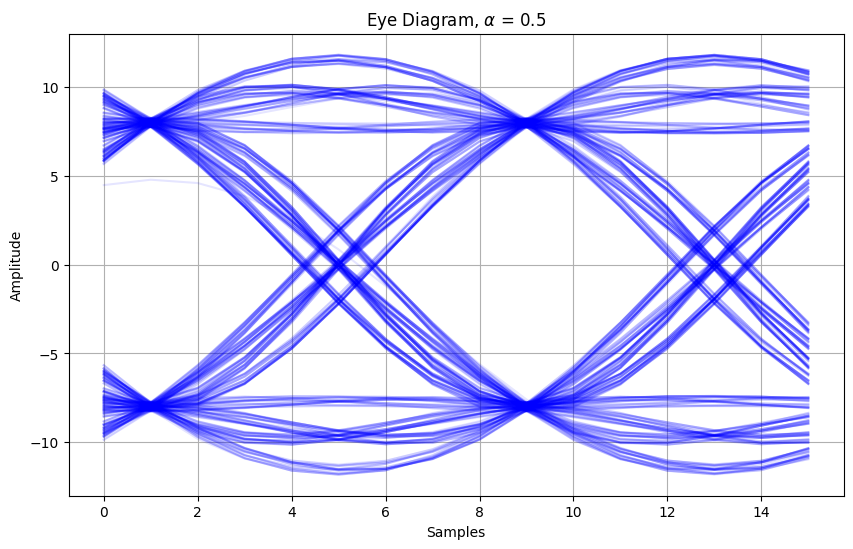

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from commpy.filters import rrcosfilter

# --- Parameters ---
Nbits = 1000       # number of random bits
sps = 8            # samples per symbol
alpha = 0.5        # roll-off factor
span = 6           # filter span in symbols

# --- Generate PAM-2 symbols (+1/-1) ---
# MATLAB: randi([0 1], Nbits, 1)
bits = np.random.randint(0, 2, Nbits)
sym = 2 * bits - 1  # map to +/- 1

# --- Upsample and Design RRC filter ---
# MATLAB: upsample(sym, sps)
sym_up = np.zeros(len(sym) * sps)
sym_up[::sps] = sym

# MATLAB: rcosdesign(alpha, span, sps, 'sqrt')
# Note: scikit-commpy requires N (total taps), Ts (symbol period), and Fs (sampling rate)
# We set Ts=1 and Fs=sps to perfectly match the discrete tap counts of MATLAB
num_taps = span * sps + 1
_, rrc_filter = rrcosfilter(N=num_taps, alpha=alpha, Ts=1.0, Fs=sps)

# --- Transmit and Matched filtering ---
# MATLAB: conv(..., 'same')
tx_signal = np.convolve(sym_up, rrc_filter, mode='same')
rx_signal = np.convolve(tx_signal, rrc_filter, mode='same')

# --- Eye diagram ---
# MATLAB: eyediagram(rx_signal, 2*sps)
window_len = 2 * sps       # Two symbol periods wide
num_windows = len(rx_signal) // window_len

plt.figure(figsize=(10, 6))

# Reshape and plot segments overlaid on top of each other
for i in range(num_windows - 1):
    # Slice a segment of 2 symbol periods
    segment = rx_signal[i * window_len : (i + 1) * window_len]
    plt.plot(segment, color='blue', alpha=0.1)  # Low alpha creates the glowing trace effect

plt.title(f"Eye Diagram, $\\alpha$ = {alpha}")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.grid(True)
plt.show()
